In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
from src.similarities import cross_similarity
from src.create_embeddings import create_embeddings as create_label_embeddings
from src.visualize import visualize_cross_similarity
from src.computations import get_captions, next_word_similarity, calculate_similarity, get_df
from src.timestamp_captions import get_timestamp_captions, create_caption_embeddings, get_images, extract_region_and_label_embeddings
from src.eaf_labels import get_eaf_labels
from aiai_dataloader.datasets import EducationDataset, load_file_dict
from thumos_dataloader import MultiTHUMOSDataset

from florence_pytorch.florence.modeling_florence2 import Florence2LanguageForConditionalGeneration as FloLanguageModel
import florence_pytorch.florence.modeling_florence2 as flor2

from transformers import AutoModelForCausalLM, AutoProcessor
from florence_pytorch.florence.processor import Florence2Processor

from dotmap import DotMap
import yaml
import torch
import random
import numpy as np
from torchvision import transforms

In [5]:
def call_florence(prompt, cropped_images, model, processor, padding=False):
    if hasattr(model, 'module'):
        flo_model = model.module
    else:
        flo_model = model

    inputs = processor(text=prompt, images=cropped_images, return_tensors="pt", padding=padding)

    input_ids = inputs["input_ids"].to(flo_model.device)
    pixel_values = inputs["pixel_values"].to(flo_model.device)
    generated_ids = flo_model.generate(
        input_ids=input_ids,
        pixel_values=pixel_values,
        max_new_tokens=512,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
    return generated_text

In [6]:
model_name = "./ckpt/caption20/"

# auto_model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
auto_model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
processor = Florence2Processor.from_pretrained(model_name, trust_remote_code=True, device_map='auto')

In [7]:
with open('./config/aiai/working_20percent.yaml', 'r') as f:
    config = yaml.safe_load(f)
cfg = DotMap(config)

In [8]:

seed = int(777)
torch.manual_seed(seed) 
torch.cuda.manual_seed(seed)  # For GPU operations
torch.cuda.manual_seed_all(seed)  # If using multiple GPUs
random.seed(seed)
np.random.seed(seed) 

print('Load file dictionary...')
file_dict, desc_list = load_file_dict(cfg.vid_dir, cfg.annot_dir, stunt=cfg.stunt)

print('Set up education dataset and test...')

# determine the train-test split
indices = np.arange(len(desc_list))
np.random.shuffle(indices)
split_idx = int(.8 * len(indices))
train_desc_list = [desc_list[ind] for ind in indices[:split_idx]]
test_desc_list = [desc_list[ind] for ind in indices[split_idx:]]

dataset_train = EducationDataset(cfg.vid_dir, cfg.annot_dir, file_dict, train_desc_list, transform=transforms.ToTensor(), size=cfg.size, label_defs=cfg.label_defs)
dataset_test = EducationDataset(cfg.vid_dir, cfg.annot_dir, file_dict, test_desc_list, transform=transforms.ToTensor(), size=cfg.size, label_defs=cfg.label_defs)
print(f'There are {len(list(dataset_train.get_file_dict().keys()))} video-eaf pairs')

Load file dictionary...
Set up education dataset and test...
There are 66 video-eaf pairs


In [9]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    image, timestamp, label = zip(*batch)
    # Check the labels for bb
    image = torch.stack(image)
    timestamps = torch.tensor(timestamp)
    labels = pad_sequence(label, batch_first=True, padding_value=-1)
    return image, timestamp, labels

train_loader = DataLoader( dataset_train, batch_size=cfg.batch_size, num_workers=cfg.workers, shuffle=True, pin_memory=False, drop_last=True,  collate_fn=collate_fn)
test_loader = DataLoader( dataset_test, batch_size=cfg.batch_size, num_workers=cfg.workers, shuffle=False, pin_memory=False, drop_last=True,  collate_fn=collate_fn)

/home/tkg5kq/.conda/envs/bound/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
data = next(iter(test_loader)) #test_loader:
# images, timestamps, labels = dataset_test[0]
print(data[0].shape)
# call_florence("<CAPTION>", images[0], auto_model, processor, padding=False)

torch.Size([16, 3, 768, 768])


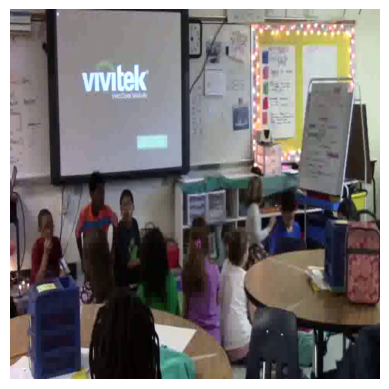

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(data[0][0].permute(1, 2, 0).numpy())
plt.axis('off')
plt.show()

In [24]:
text = call_florence("<CAPTION>", data[0][1], auto_model, processor, padding=False)

In [14]:
detailed = call_florence("<DETAILED_CAPTION>", data[0][0], auto_model, processor, padding=False)

In [20]:
more_detailed = call_florence("<MORE_DETAILED_CAPTION>", data[0][0], auto_model, processor, padding=False)

In [25]:
print(text)
print(detailed)
print(more_detailed)

[',,, at at, at,, in at at at in, at in at, in,, a at at a at, a, at a,, on at at on, at on at, on,,  at at , at  at, ,,. at at. at,., at.,,']
[',,, at, at at at,, in, at in, in at, in in,, on, at on,, a,,']
[',,, at, at at,, in at, in,, on,,s,,']
